# 06 — Stance Detection with DistilBERT (FNC-1 Dataset)

Fine-tune **distilbert-base-uncased** for 3-class stance detection:

| Label | Meaning |
|-------|---------|
| **Support** | The body agrees with the headline |
| **Against** | The body disagrees with the headline |
| **Neutral** | The body discusses the topic without taking a side, or is unrelated |

This follows the TF-IDF baseline in `05_stance_baseline.ipynb`.

| Step | Description |
|------|-------------|
| 1 | Load & merge FNC-1 data |
| 2 | Simplify labels (4 → 3 classes) |
| 3 | Preprocess & combine headline + body |
| 4 | Train / Validation / Test split |
| 5 | Tokenize with DistilBERT tokenizer |
| 6 | Fine-tune with Hugging Face Trainer |
| 7 | Evaluate on test set |
| 8 | Plot loss curves & confusion matrix |
| 9 | Save model & tokenizer |
| 10 | Inference function |

## 0. Imports & Device Setup

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"Device  : {DEVICE}")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5090
Device  : cuda


---
## 1. Load & Merge Data

In [2]:
stances = pd.read_csv("train_stances.csv")
bodies  = pd.read_csv("train_bodies.csv")

print(f"Stances : {stances.shape}  |  Columns: {stances.columns.tolist()}")
print(f"Bodies  : {bodies.shape}   |  Columns: {bodies.columns.tolist()}")

# Merge on Body ID
df = stances.merge(bodies, on="Body ID", how="left")
print(f"\nMerged  : {df.shape}")
print(f"Missing : {df.isnull().sum().sum()}")

print(f"\nOriginal stance distribution:")
print(df["Stance"].value_counts().to_string())

Stances : (49972, 3)  |  Columns: ['Headline', 'Body ID', 'Stance']
Bodies  : (1683, 2)   |  Columns: ['Body ID', 'articleBody']

Merged  : (49972, 4)
Missing : 0

Original stance distribution:
Stance
unrelated    36545
discuss       8909
agree         3678
disagree       840


---
## 2. Label Simplification (4 → 3 classes)

| Original | → | Simplified | Integer |
|----------|---|------------|---------|
| agree | → | Support | 0 |
| disagree | → | Against | 1 |
| discuss | → | Neutral | 2 |
| unrelated | → | Neutral | 2 |

Simplified distribution:
label_name
Neutral    45454
Support     3678
Against      840


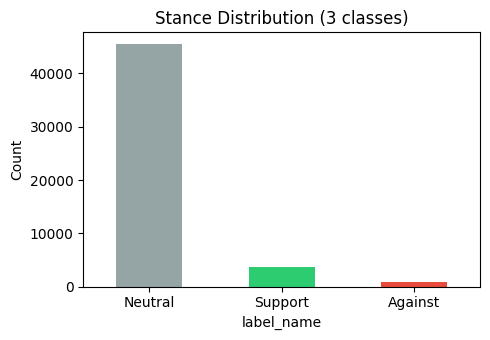


Note: 'Against' has only 840 samples — very imbalanced.


In [3]:
LABEL_MAP = {
    "agree":     "Support",
    "disagree":  "Against",
    "discuss":   "Neutral",
    "unrelated": "Neutral",
}

LABEL_TO_ID = {"Support": 0, "Against": 1, "Neutral": 2}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

df["label_name"] = df["Stance"].map(LABEL_MAP)
df["label"]      = df["label_name"].map(LABEL_TO_ID)

print("Simplified distribution:")
print(df["label_name"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(5, 3.5))
df["label_name"].value_counts().plot(
    kind="bar", ax=ax, rot=0,
    color=["#95a5a6", "#2ecc71", "#e74c3c"],
)
ax.set_title("Stance Distribution (3 classes)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"\nNote: 'Against' has only {(df['label_name']=='Against').sum()} samples — very imbalanced.")

---
## 3. Preprocessing

Combine headline and body with `[SEP]` — this tells the model  
the two parts are related but separate, similar to BERT sentence-pair tasks.

In [4]:
def clean_text(text):
    """Basic text cleaning."""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)  # collapse whitespace
    return text


df["content"] = (
    df["Headline"].apply(clean_text)
    + " [SEP] "
    + df["articleBody"].apply(clean_text)
)

print("Sample (first 200 chars):")
print(df["content"].iloc[0][:200])
print(f"\nContent length stats:")
print(df["content"].str.len().describe().round(0).to_string())

Sample (first 200 chars):
Police find mass graves with at least '15 bodies' near Mexico town where 43 students disappeared after police clash [SEP] Danny Boyle is directing the untitled film Seth Rogen is being eyed to play Ap

Content length stats:
count    49972.0
mean      2273.0
std       1669.0
min         62.0
25%       1240.0
50%       1892.0
75%       2825.0
max      27564.0


---
## 4. Train / Validation / Test Split (70 / 15 / 15)

In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = split["label_name"].value_counts().to_dict()
    print(f"{name:>5}: {len(split):>6} rows  |  Support={dist.get('Support',0):>5}  Against={dist.get('Against',0):>4}  Neutral={dist.get('Neutral',0):>6}")

Train:  34980 rows  |  Support= 2575  Against= 588  Neutral= 31817
  Val:   7496 rows  |  Support=  551  Against= 126  Neutral=  6819
 Test:   7496 rows  |  Support=  552  Against= 126  Neutral=  6818


---
## 5. Tokenization

| Setting | Value | Reason |
|---------|-------|--------|
| `max_length` | 256 | Captures headline + beginning of body |
| `truncation` | True | Prevents errors on long articles |
| `padding` | `max_length` | Uniform tensor shape for batching |

In [6]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"Tokenizer  : {MODEL_NAME}")
print(f"Vocab size : {tokenizer.vocab_size:,}")

Tokenizer  : distilbert-base-uncased
Vocab size : 30,522


In [7]:
class StanceDataset(Dataset):
    """Wraps a DataFrame for the Hugging Face Trainer."""

    def __init__(self, dataframe, tokenizer, max_length):
        self.texts      = dataframe["content"].tolist()
        self.labels     = dataframe["label"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = StanceDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = StanceDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = StanceDataset(test_df,  tokenizer, MAX_LENGTH)

print(f"Datasets — Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

Datasets — Train: 34980  Val: 7496  Test: 7496


---
## 6. Fine-Tune DistilBERT

Settings kept lightweight: **2 epochs, batch size 8** so it runs  
in a reasonable time even on CPU.

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3,
)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:>12,}")
print(f"Trainable parameters : {train_:>12,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     :   66,955,779
Trainable parameters :   66,955,779


In [9]:
def compute_metrics(eval_pred):
    """Called by Trainer at the end of each evaluation phase."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [10]:
SAVE_DIR = "models/stance_model"

training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready. Starting training...


In [11]:
train_result = trainer.train()

print(f"\nTraining complete.")
print(f"  Total steps   : {train_result.global_step}")
print(f"  Training loss : {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.115708,0.132875,0.960245,0.775232,0.631209,0.627010
2,0.121613,0.105241,0.973052,0.817023,0.764427,0.782904


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete.
  Total steps   : 8746
  Training loss : 0.1648


---
## 7. Evaluate on Test Set

In [12]:
test_output = trainer.predict(test_dataset)
test_preds  = np.argmax(test_output.predictions, axis=-1)
test_labels = test_df["label"].values

m = test_output.metrics
print("=" * 50)
print("   STANCE DETECTION — TEST RESULTS")
print("=" * 50)
print(f"  Accuracy       : {m['test_accuracy']:.4f}")
print(f"  Precision (macro): {m['test_precision']:.4f}")
print(f"  Recall    (macro): {m['test_recall']:.4f}")
print(f"  F1 Score  (macro): {m['test_f1']:.4f}")
print("=" * 50)

label_names = [ID_TO_LABEL[i] for i in range(3)]
print(f"\n{classification_report(test_labels, test_preds, target_names=label_names)}")

   STANCE DETECTION — TEST RESULTS
  Accuracy       : 0.9705
  Precision (macro): 0.7990
  Recall    (macro): 0.7393
  F1 Score  (macro): 0.7589

              precision    recall  f1-score   support

     Support       0.80      0.86      0.83       552
     Against       0.61      0.37      0.46       126
     Neutral       0.99      0.99      0.99      6818

    accuracy                           0.97      7496
   macro avg       0.80      0.74      0.76      7496
weighted avg       0.97      0.97      0.97      7496



---
## 8. Visualizations

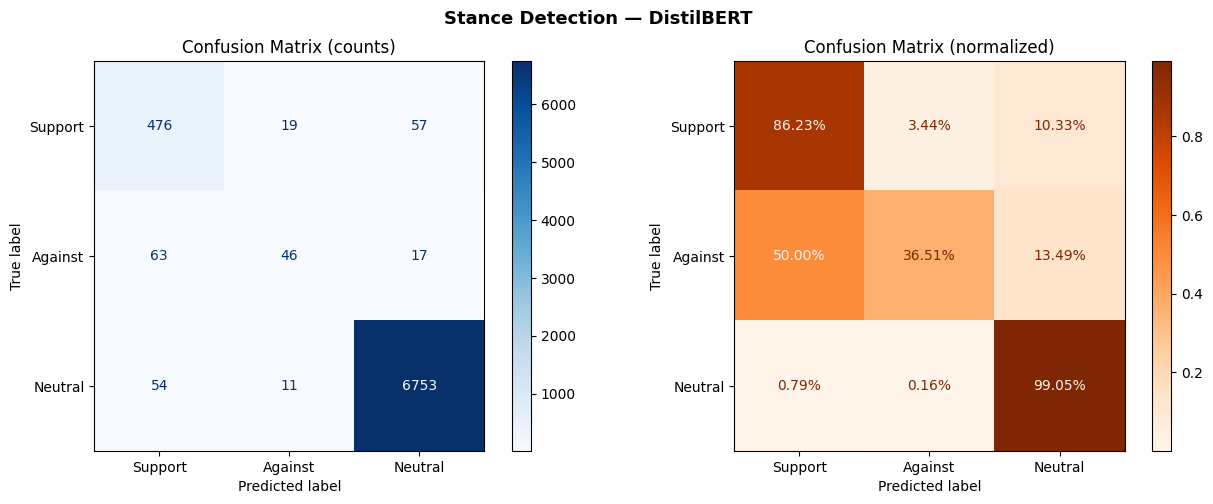

In [13]:
# ---- Confusion Matrix ----
cm = confusion_matrix(test_labels, test_preds, labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
    ax=axes[0], cmap="Blues", values_format="d"
)
axes[0].set_title("Confusion Matrix (counts)")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(
    ax=axes[1], cmap="Oranges", values_format=".2%"
)
axes[1].set_title("Confusion Matrix (normalized)")

plt.suptitle("Stance Detection — DistilBERT", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

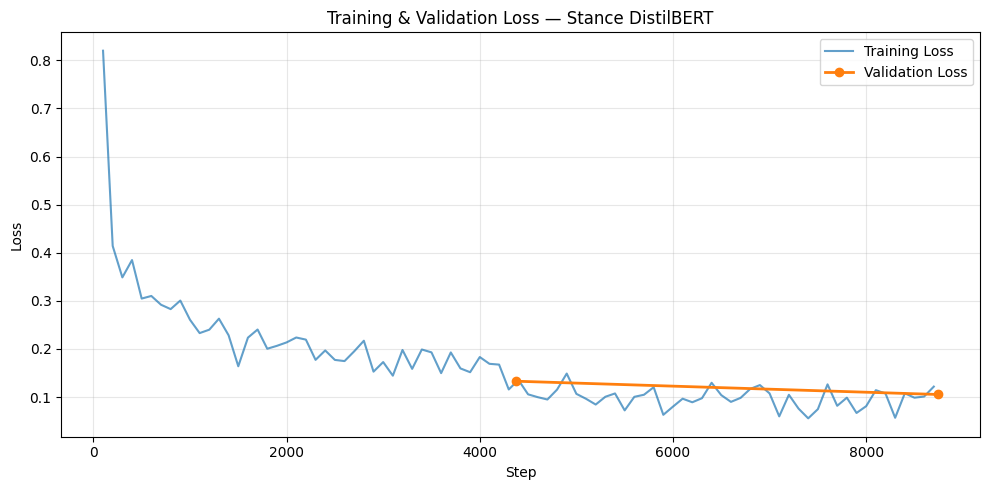

In [14]:
# ---- Training & Validation Loss Curves ----
log = trainer.state.log_history

train_steps = [e["step"] for e in log if "loss" in e]
train_loss  = [e["loss"] for e in log if "loss" in e]
eval_steps  = [e["step"] for e in log if "eval_loss" in e]
eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Training Loss", alpha=0.7)
ax.plot(eval_steps, eval_loss, label="Validation Loss", marker="o", linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss — Stance DistilBERT")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Save Model & Tokenizer

In [15]:
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Saved to: {SAVE_DIR}/")
for f in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f)
    if os.path.isfile(fpath):
        print(f"  {f:<45} {os.path.getsize(fpath)/1024:>10.1f} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: models/stance_model/
  config.json                                          0.8 KB
  model.safetensors                               261558.2 KB
  tokenizer.json                                     695.0 KB
  tokenizer_config.json                                0.3 KB
  training_args.bin                                    5.1 KB


---
## 10. Inference Function

In [16]:
# Load saved model for inference
inf_tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
inf_model     = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
inf_model.to(DEVICE)
inf_model.eval()
print(f"Inference model loaded from {SAVE_DIR}")


def predict_stance(headline: str, body: str) -> dict:
    """
    Predict the stance of a body text toward a headline.

    Args:
        headline: The claim / headline.
        body:     The article body text.

    Returns:
        {"label": "Support"/"Against"/"Neutral", "confidence": float}
    """
    text = clean_text(headline) + " [SEP] " + clean_text(body)

    inputs = inf_tokenizer(
        text,
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        logits = inf_model(**inputs).logits

    probs      = F.softmax(logits, dim=-1).squeeze()
    pred_id    = torch.argmax(probs).item()
    confidence = probs[pred_id].item()

    return {
        "label": ID_TO_LABEL[pred_id],
        "confidence": round(confidence, 4),
    }

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Inference model loaded from models/stance_model


In [17]:
# Quick demo
examples = [
    {
        "headline": "New study confirms vaccines are safe and effective",
        "body": (
            "Researchers at Johns Hopkins University published findings that "
            "confirm the safety and efficacy of current vaccines. The study "
            "reviewed data from over 10 million patients."
        ),
    },
    {
        "headline": "City to ban all cars from downtown area",
        "body": (
            "The mayor's office denied rumors of a car ban. Officials stated "
            "that no such policy is under consideration and traffic will "
            "continue as normal."
        ),
    },
    {
        "headline": "Tech company announces record profits",
        "body": (
            "A new species of frog was discovered in the Amazon rainforest "
            "by a team of biologists from Brazil. The frog has a unique "
            "blue coloration."
        ),
    },
]

print(f"{'Headline':<52} {'Stance':>8}  {'Conf':>6}")
print("-" * 72)
for ex in examples:
    r = predict_stance(ex["headline"], ex["body"])
    print(f"{ex['headline'][:50]:<52} {r['label']:>8}  {r['confidence']:>5.1%}")

Headline                                               Stance    Conf
------------------------------------------------------------------------
New study confirms vaccines are safe and effective    Support  96.3%
City to ban all cars from downtown area               Support  47.4%
Tech company announces record profits                 Neutral  100.0%


---
## Summary

| Item | Detail |
|------|--------|
| Dataset | FNC-1 (`train_stances.csv` + `train_bodies.csv`) |
| Samples | 49,972 headline–body pairs |
| Labels | Support (0) / Against (1) / Neutral (2) |
| Base model | `distilbert-base-uncased` (66M params) |
| Max length | 256 tokens |
| Split | 70 / 15 / 15 (stratified) |
| Training | 2 epochs, batch=8, lr=2e-5 |
| Saved to | `models/stance_model/` |

### Why Headline + Body matters

Stance detection is a **sentence-pair task** — the model needs both pieces  
to determine whether the body supports, contradicts, or ignores the headline.  
The `[SEP]` token helps the model learn this boundary.

### Limitations

- **Class imbalance**: "Against" has very few training samples (~840) → low recall
- **Truncation**: Bodies are often 2000+ characters; `max_length=256` only captures the beginning
- **Merged labels**: Combining "discuss" + "unrelated" into "Neutral" hides an important distinction
- **2 epochs**: Minimal training — more epochs could help but risk overfitting on small classes